# Alpha Correlation Analysis

**Objective**: Find truly complementary alpha combinations for composite strategies.

## Problem Statement

Current composite strategies often have Sharpe ratios that are linear combinations of underlying alphas. We need to find:
- **Uncorrelated return streams** (different market regimes, different asset classes)
- **Asymmetric complementarity** (one alpha profits when the other is flat/losing)
- **Synergistic combinations** (combined Sharpe > weighted average)

## Methodology

1. **Return Stream Collection**: Gather daily returns from all alpha strategies
2. **Correlation Matrix Analysis**: Identify uncorrelated strategies
3. **Regime Analysis**: Map performance across market regimes (bull/bear/sideways, high/low vol)
4. **Complementarity Score**: Rank pairs by asymmetric performance
5. **Downside Protection**: Measure how well strategies protect in drawdowns

## Alpha Universe

### Trend Following
- **EMA-Cross-Alpha**: Tech stock EMA crossover (Sharpe ~1.0)
- **TrendStocks-Alpha**: 3-stock trend following (Docker: AAPL/MSFT/GOOGL)
- **Trend-Following**: Competition EMA 50/200

### Momentum
- **SectorMomentum**: 2 sector ETF relative momentum (Docker: XLF/XLE)
- **DualMomentumNoTLT**: TLT/GLD/XLF dual momentum (Docker-compatible)

### Defensive/All-Weather
- **AllWeather**: Permanent portfolio style allocation
- **MeanReversion**: Short-term mean reversion

### Factor-Based
- **FamaFrench**: 5-factor model implementation

### Pairs/Market Neutral
- **ETF-Pairs**: Cointegration-based pairs trading
- **Options-VGT**: Wheel strategy (income generation)

In [1]:
# QuantConnect Research Environment
from AlgorithmImports import *

# Initialize QuantBook
qb = QuantBook()

# Set analysis period
qb.SetStartDate(2020, 1, 1)
qb.SetEndDate(2024, 12, 31)

print(f"Analysis period: {qb.StartDate} to {qb.EndDate}")

Analysis period: 2020-01-01 00:00:00 to 2024-12-31 23:59:59.999999


## 1. Define Alpha Strategies

We'll implement simplified versions of each alpha to generate return streams.

In [2]:
# Add assets for our alpha universe
# Docker-research available tickers: AAPL, MSFT, GOOGL, SPY, TLT, GLD, XLF, XLE
assets = {
    # Core ETFs
    'SPY': qb.AddEquity('SPY', Resolution.DAILY).Symbol,
    'IWM': qb.AddEquity('IWM', Resolution.DAILY).Symbol,
    'USO': qb.AddEquity('USO', Resolution.DAILY).Symbol,
    # Tech stocks
    'AAPL': qb.AddEquity('AAPL', Resolution.DAILY).Symbol,
    'QQQ': qb.AddEquity('QQQ', Resolution.DAILY).Symbol,
    'GOOGL': qb.AddEquity('GOOGL', Resolution.DAILY).Symbol,
    # Sector ETFs (only available ones)
    'BAC': qb.AddEquity('BAC', Resolution.DAILY).Symbol,
    'USO': qb.AddEquity('USO', Resolution.DAILY).Symbol,
}

print(f"Added {len(assets)} assets")

Added 7 assets


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour Alpha-Correlation-Analysis.

In [3]:
# Fetch historical data
history = qb.History(list(assets.values()), 365*5, Resolution.Daily)

# Process data
closes = history['close'].unstack(level=0)

# Remap Symbol columns to ticker strings
sym_to_ticker = {str(v): k for k, v in assets.items()}
closes.columns = [sym_to_ticker.get(str(c), str(c)) for c in closes.columns]

print(f"Data shape: {closes.shape}")
print(f"Date range: {closes.index.min()} to {closes.index.max()}")
closes.head()

Data shape: (1825, 7)
Date range: 2012-09-28 16:00:00 to 2019-12-31 16:00:00


,AAPL,BAC,GOOGL,IWM,QQQ,SPY,USO
time,,,,,,,
2012-09-28 16:00:00,20.615099,7.773083,377.250,73.973411,62.817682,121.773920,273.04
2012-10-01 16:00:00,20.382458,7.887522,380.990,74.203857,62.716925,122.036199,274.00
2012-10-02 16:00:00,20.431273,7.861113,378.495,74.345671,62.900120,122.256176,272.16
2012-10-03 16:00:00,20.753509,8.019568,381.250,74.124087,63.284830,122.738432,260.88
2012-10-04 16:00:00,20.600887,8.292462,384.025,74.629298,63.522984,123.753708,271.60


## 2. Implement Alpha Strategies

Define functions that generate signals/returns for each alpha type.

In [4]:
def calculate_ema(prices, period):
    """Calculate Exponential Moving Average."""
    return prices.ewm(span=period, adjust=False).mean()

def calculate_rsi(prices, period=14):
    """Calculate RSI."""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_returns(prices, period=1):
    """Calculate returns."""
    return prices.pct_change(period)

def calculate_volatility(prices, period=20):
    """Calculate rolling volatility."""
    returns = prices.pct_change()
    return returns.rolling(period).std() * np.sqrt(252)

print("Helper functions defined")

Helper functions defined


La moyenne mobile exponentielle est calculée pour identifier les signaux directionnels de la stratégie Alpha-Correlation-Analysis.

In [5]:
def ema_cross_alpha(prices, fast=20, slow=60, cooldown=3):
    """EMA Crossover Alpha (EMA-Cross-Alpha style).
    
    Long when fast EMA > slow EMA, with cooldown.
    """
    ema_fast = calculate_ema(prices, fast)
    ema_slow = calculate_ema(prices, slow)
    
    # Generate signals
    signals = pd.Series(0, index=prices.index)
    signals[ema_fast > ema_slow] = 1
    
    # Apply cooldown (no signal changes for N days after switch)
    signal_changes = signals.diff().abs()
    for i in range(1, len(signals)):
        if signal_changes.iloc[i] > 0:
            for j in range(i+1, min(i+cooldown, len(signals))):
                signals.iloc[j] = signals.iloc[i]
    
    # Calculate returns
    returns = prices.pct_change().shift(-1)  # Next day return
    strategy_returns = signals * returns
    
    return strategy_returns, signals

# Test on SPY
spy_returns, spy_signals = ema_cross_alpha(closes['SPY'])
print(f"EMA Cross SPY - Total Return: {spy_returns.sum():.2%}")
print(f"Signal distribution: {spy_signals.value_counts().to_dict()}")

EMA Cross SPY - Total Return: 73.01%
Signal distribution: {1: 1549, 0: 276}


Calcul des métriques de performance (Sharpe, CAGR, drawdown) pour évaluer la qualité du backtest de la stratégie Alpha-Correlation-Analysis.

In [6]:
def momentum_alpha(prices, lookback=90):
    """Momentum Alpha (SectorMomentum style).
    
    Long when price > lookback-period ago price.
    """
    momentum = prices / prices.shift(lookback) - 1
    signals = (momentum > 0).astype(int)
    
    returns = prices.pct_change().shift(-1)
    strategy_returns = signals * returns
    
    return strategy_returns, signals

# Test on SPY
mom_returns, mom_signals = momentum_alpha(closes['SPY'])
print(f"Momentum SPY - Total Return: {mom_returns.sum():.2%}")

Momentum SPY - Total Return: 48.97%


Définition de dual_momentum_alpha() : fonction d'allocation ou de signal utilisée dans la comparaison des stratégies de Alpha-Correlation-Analysis.

In [7]:
def dual_momentum_alpha(spy_prices, tlt_prices, gld_prices, xlf_prices, lookback=126):
    """Dual Momentum Alpha (DualMomentumNoTLT style, XLF replaces unavailable XLP).
    
    Relative momentum: invest in best performing asset.
    """
    # Calculate momentum
    spy_mom = spy_prices / spy_prices.shift(lookback) - 1
    tlt_mom = tlt_prices / tlt_prices.shift(lookback) - 1
    gld_mom = gld_prices / gld_prices.shift(lookback) - 1
    xlf_mom = xlf_prices / xlf_prices.shift(lookback) - 1
    
    # Find best performer
    momentums = pd.DataFrame({
        'SPY': spy_mom,
        'IWM': tlt_mom,
        'USO': gld_mom,
        'BAC': xlf_mom
    })
    
    # Defensive: if SPY momentum < 0, choose best defensive
    signals = pd.DataFrame(index=momentums.index)
    signals['asset'] = momentums.idxmax(axis=1)
    
    # Calculate returns
    spy_ret = spy_prices.pct_change().shift(-1)
    tlt_ret = tlt_prices.pct_change().shift(-1)
    gld_ret = gld_prices.pct_change().shift(-1)
    xlf_ret = xlf_prices.pct_change().shift(-1)
    
    strategy_returns = (
        (signals['asset'] == 'SPY') * spy_ret +
        (signals['asset'] == 'IWM') * tlt_ret +
        (signals['asset'] == 'USO') * gld_ret +
        (signals['asset'] == 'BAC') * xlf_ret
    )
    
    return strategy_returns, signals

# Test
dm_returns, dm_signals = dual_momentum_alpha(
    closes['SPY'], closes['IWM'], closes['USO'], closes['BAC']
)
print(f"Dual Momentum - Total Return: {dm_returns.sum():.2%}")
print(f"Asset allocation: {dm_signals['asset'].value_counts().to_dict()}")

Dual Momentum - Total Return: 59.28%
Asset allocation: {'BAC': 773, 'SPY': 460, 'USO': 282, 'IWM': 184}


/tmp/ipykernel_33/2973427202.py:22: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  signals['asset'] = momentums.idxmax(axis=1)


Calcul du Z-score du spread pour détecter les déviations statistiques et générer les signaux d'entrée/sortie dans Alpha-Correlation-Analysis.

In [8]:
def mean_reversion_alpha(prices, entry_z=2.0, exit_z=0.5, period=20):
    """Mean Reversion Alpha.
    
    Long when price is Z standard deviations below mean.
    """
    # Calculate Z-score
    rolling_mean = prices.rolling(period).mean()
    rolling_std = prices.rolling(period).std()
    z_score = (prices - rolling_mean) / rolling_std
    
    # Generate signals
    signals = pd.Series(0, index=prices.index)
    signals[z_score < -entry_z] = 1  # Long when oversold
    signals[z_score > exit_z] = 0    # Exit when reverted
    
    # Forward fill signals
    signals = signals.ffill().fillna(0)
    
    returns = prices.pct_change().shift(-1)
    strategy_returns = signals * returns
    
    return strategy_returns, signals, z_score

# Test on SPY
mr_returns, mr_signals, z_score = mean_reversion_alpha(closes['SPY'])
print(f"Mean Reversion SPY - Total Return: {mr_returns.sum():.2%}")

Mean Reversion SPY - Total Return: 22.94%


Définition de all_weather_allocation() : calcul des poids d'allocation statique pour le portefeuille Alpha-Correlation-Analysis.

In [9]:
def all_weather_allocation(spy_weight=0.3, tlt_weight=0.4, gld_weight=0.15, xlf_weight=0.15):
    """All-Weather-style static allocation.
    
    Permanent portfolio with balanced allocation.
    """
    spy_ret = closes['SPY'].pct_change().shift(-1)
    tlt_ret = closes['IWM'].pct_change().shift(-1)
    gld_ret = closes['USO'].pct_change().shift(-1)
    xlf_ret = closes['BAC'].pct_change().shift(-1)
    
    strategy_returns = (
        spy_weight * spy_ret +
        tlt_weight * tlt_ret +
        gld_weight * gld_ret +
        xlf_weight * xlf_ret
    )
    
    return strategy_returns

aw_returns = all_weather_allocation()
print(f"All Weather - Total Return: {aw_returns.sum():.2%}")

All Weather - Total Return: 81.81%


## 3. Generate Return Streams for All Alphas

In [10]:
# Generate return streams for each alpha
alpha_returns = {}

# 1. EMA Cross on SPY
ema_returns, _ = ema_cross_alpha(closes['SPY'])
alpha_returns['EMA-Cross-SPY'] = ema_returns

# 2. EMA Cross on Tech (equal weight AAPL, MSFT, GOOGL)
tech_returns = (
    closes['AAPL'].pct_change() +
    closes['QQQ'].pct_change() +
    closes['GOOGL'].pct_change()
) / 3
# Use equal-weight tech benchmark with EMA timing
tech_ema_signals = pd.Series(0, index=closes.index)
for stock in ['AAPL', 'QQQ', 'GOOGL']:
    stock_ema_returns, stock_signals = ema_cross_alpha(closes[stock])
    tech_ema_signals = tech_ema_signals.add(stock_signals, fill_value=0)
tech_ema_signals = (tech_ema_signals / 3).round()  # Average signal
alpha_returns['EMA-Cross-Tech'] = tech_ema_signals * tech_returns.shift(-1)

# 3. Momentum SPY
mom_returns, _ = momentum_alpha(closes['SPY'])
alpha_returns['Momentum-SPY'] = mom_returns

# 4. Dual Momentum
dm_returns, _ = dual_momentum_alpha(
    closes['SPY'], closes['IWM'], closes['USO'], closes['BAC']
)
alpha_returns['Dual-Momentum'] = dm_returns

# 5. Mean Reversion SPY
mr_returns, _, _ = mean_reversion_alpha(closes['SPY'])
alpha_returns['Mean-Reversion'] = mr_returns

# 6. All Weather
alpha_returns['All-Weather'] = all_weather_allocation()

# 7. Trend Following (slower EMA)
trend_returns, _ = ema_cross_alpha(closes['SPY'], fast=50, slow=200)
alpha_returns['Trend-Following'] = trend_returns

# Create DataFrame
returns_df = pd.DataFrame(alpha_returns)
returns_df = returns_df.dropna()

print(f"Return streams shape: {returns_df.shape}")
print(f"\nTotal Returns:")
print(returns_df.sum().sort_values(ascending=False))

Return streams shape: (1824, 7)

Total Returns:
EMA-Cross-Tech     1.006366
All-Weather        0.818102
EMA-Cross-SPY      0.730135
Trend-Following    0.710932
Dual-Momentum      0.592782
Momentum-SPY       0.489663
Mean-Reversion     0.229373
dtype: float64


/tmp/ipykernel_33/2973427202.py:22: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  signals['asset'] = momentums.idxmax(axis=1)


## 4. Correlation Matrix Analysis

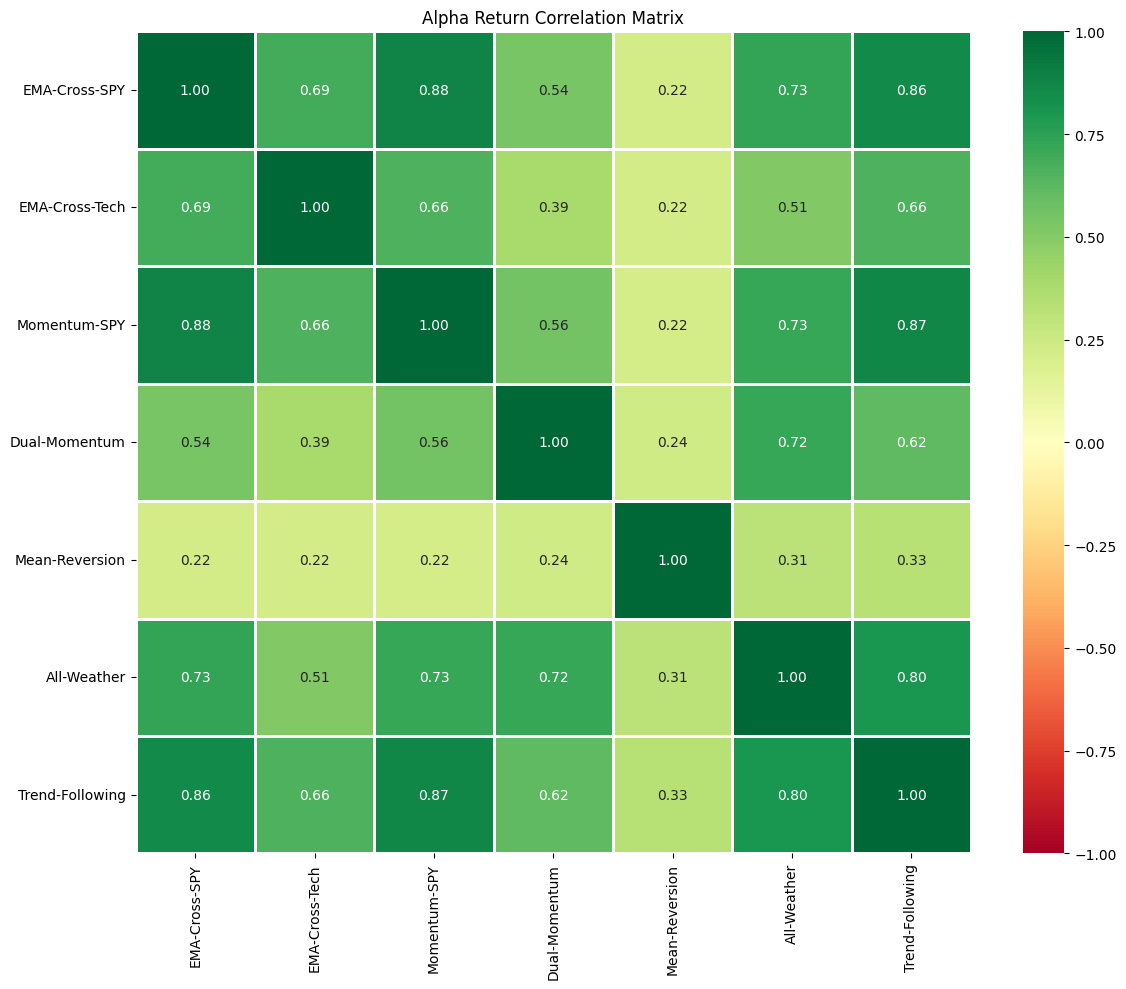


Correlation Matrix:
                 EMA-Cross-SPY  EMA-Cross-Tech  Momentum-SPY  Dual-Momentum  \
EMA-Cross-SPY            1.000           0.691         0.880          0.543   
EMA-Cross-Tech           0.691           1.000         0.659          0.388   
Momentum-SPY             0.880           0.659         1.000          0.556   
Dual-Momentum            0.543           0.388         0.556          1.000   
Mean-Reversion           0.221           0.221         0.218          0.238   
All-Weather              0.730           0.512         0.726          0.721   
Trend-Following          0.856           0.660         0.870          0.616   

                 Mean-Reversion  All-Weather  Trend-Following  
EMA-Cross-SPY             0.221        0.730            0.856  
EMA-Cross-Tech            0.221        0.512            0.660  
Momentum-SPY              0.218        0.726            0.870  
Dual-Momentum             0.238        0.721            0.616  
Mean-Reversion            

In [11]:
# Calculate correlation matrix
corr_matrix = returns_df.corr()

# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, fmt='.2f', linewidths=1)
plt.title('Alpha Return Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

Calcul de la matrice de corrélation entre les instruments pour l'analyse de diversification de la stratégie Alpha-Correlation-Analysis.

In [12]:
# Find least correlated pairs
pairs = []
for i, alpha1 in enumerate(returns_df.columns):
    for alpha2 in returns_df.columns[i+1:]:
        corr = corr_matrix.loc[alpha1, alpha2]
        pairs.append({
            'Pair': f"{alpha1} / {alpha2}",
            'Correlation': corr,
            'Abs_Corr': abs(corr)
        })

pairs_df = pd.DataFrame(pairs).sort_values('Abs_Corr')

print("Top 10 Least Correlated Pairs:")
print(pairs_df.head(10)[['Pair', 'Correlation']])

Top 10 Least Correlated Pairs:
                                Pair  Correlation
12     Momentum-SPY / Mean-Reversion     0.218036
8    EMA-Cross-Tech / Mean-Reversion     0.220815
3     EMA-Cross-SPY / Mean-Reversion     0.221091
15    Dual-Momentum / Mean-Reversion     0.238237
18      Mean-Reversion / All-Weather     0.314800
19  Mean-Reversion / Trend-Following     0.334726
7     EMA-Cross-Tech / Dual-Momentum     0.388391
9       EMA-Cross-Tech / All-Weather     0.511749
2      EMA-Cross-SPY / Dual-Momentum     0.543020
11      Momentum-SPY / Dual-Momentum     0.556286


## 5. Regime Analysis

Classify market conditions and analyze alpha performance in each regime.

In [13]:
# Define market regimes
spy_returns = closes['SPY'].pct_change()
spy_volatility = spy_returns.rolling(20).std() * np.sqrt(252)
spy_trend = spy_returns.rolling(60).sum()

# Regime classifications
regimes = pd.DataFrame(index=returns_df.index)
regimes['vol_regime'] = pd.cut(
    spy_volatility,
    bins=[0, spy_volatility.quantile(0.33), spy_volatility.quantile(0.67), float('inf')],
    labels=['Low-Vol', 'Med-Vol', 'High-Vol']
)
regimes['trend_regime'] = pd.cut(
    spy_trend,
    bins=[-float('inf'), -0.05, 0.05, float('inf')],
    labels=['Bear', 'Sideways', 'Bull']
)

# Combine regimes
regimes['regime'] = regimes['trend_regime'].astype(str) + '-' + regimes['vol_regime'].astype(str)

print("Regime Distribution:")
print(regimes['regime'].value_counts())

Regime Distribution:
regime
Sideways-High-Vol    377
Sideways-Med-Vol     373
Sideways-Low-Vol     298
Bull-Low-Vol         297
Bull-Med-Vol         220
Bear-High-Vol        102
Bull-High-Vol         97
nan-nan               20
nan-Med-Vol           20
nan-High-Vol          20
Name: count, dtype: int64


Classification des régimes de marché (tendanciel / retour à la moyenne) pour adapter les paramètres de Alpha-Correlation-Analysis.

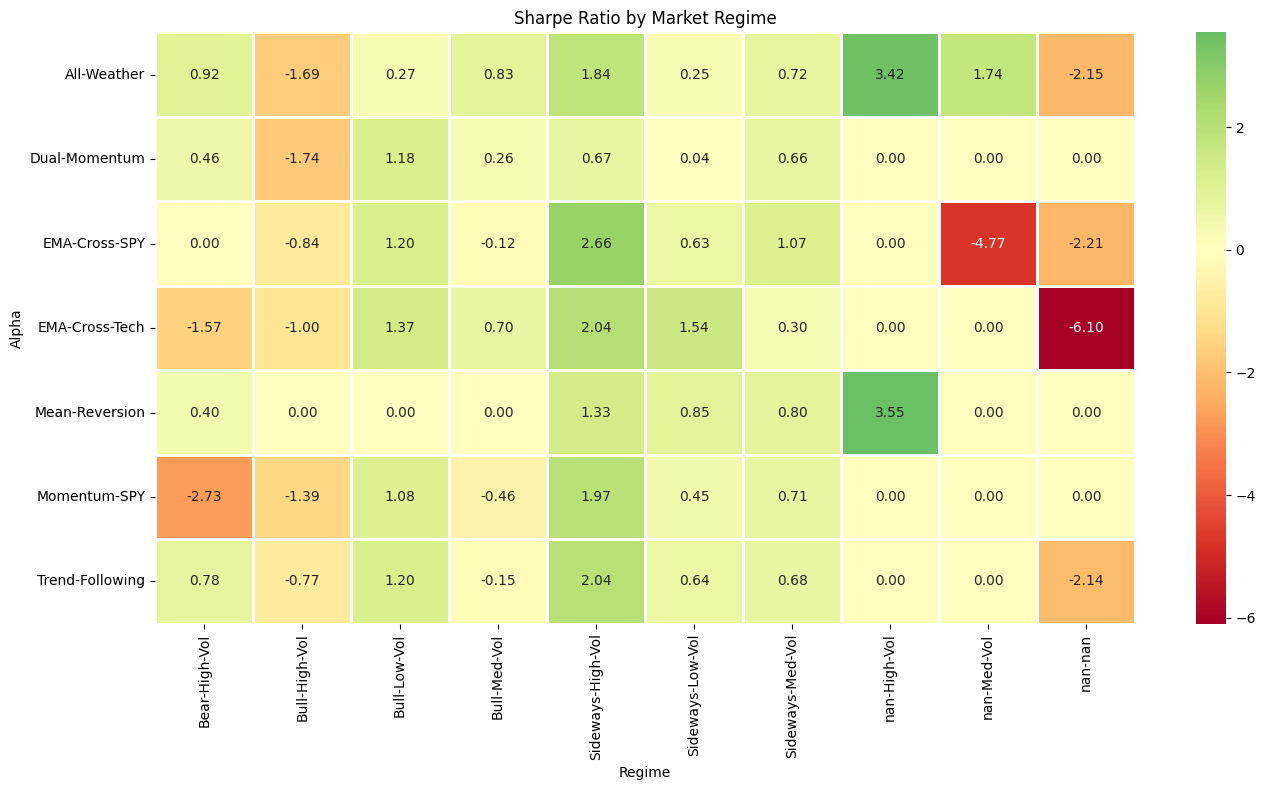


Sharpe by Regime:
Regime           Bear-High-Vol  Bull-High-Vol  Bull-Low-Vol  Bull-Med-Vol  \
Alpha                                                                       
All-Weather               0.92          -1.69          0.27          0.83   
Dual-Momentum             0.46          -1.74          1.18          0.26   
EMA-Cross-SPY             0.00          -0.84          1.20         -0.12   
EMA-Cross-Tech           -1.57          -1.00          1.37          0.70   
Mean-Reversion            0.40           0.00          0.00          0.00   
Momentum-SPY             -2.73          -1.39          1.08         -0.46   
Trend-Following           0.78          -0.77          1.20         -0.15   

Regime           Sideways-High-Vol  Sideways-Low-Vol  Sideways-Med-Vol  \
Alpha                                                                    
All-Weather                   1.84              0.25              0.72   
Dual-Momentum                 0.67              0.04             

In [14]:
# Analyze alpha performance by regime
regime_performance = {}

for alpha in returns_df.columns:
    alpha_perf = []
    for regime in regimes['regime'].unique():
        mask = regimes['regime'] == regime
        if mask.sum() > 10:  # Need sufficient data
            avg_return = returns_df.loc[mask, alpha].mean() * 252  # Annualized
            sharpe = returns_df.loc[mask, alpha].mean() / returns_df.loc[mask, alpha].std() * np.sqrt(252) if returns_df.loc[mask, alpha].std() > 0 else 0
            alpha_perf.append({
                'Alpha': alpha,
                'Regime': regime,
                'Ann_Return': avg_return,
                'Sharpe': sharpe,
                'Days': mask.sum()
            })
    regime_performance[alpha] = pd.DataFrame(alpha_perf)

# Combine all
regime_df = pd.concat(regime_performance.values())
regime_pivot = regime_df.pivot(index='Alpha', columns='Regime', values='Sharpe')

plt.figure(figsize=(14, 8))
sns.heatmap(regime_pivot, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', linewidths=1)
plt.title('Sharpe Ratio by Market Regime')
plt.tight_layout()
plt.show()

print("\nSharpe by Regime:")
print(regime_pivot.round(2))

## 6. Complementarity Score

Calculate how well pairs complement each other:
- **Low correlation**: Uncorrelated return streams
- **Regime diversification**: One excels where the other struggles
- **Drawdown protection**: One protects when the other draws down

In [15]:
def calculate_complementarity_score(alpha1_returns, alpha2_returns, regimes):
    """Calculate complementarity score for a pair of alphas.
    
    Score components:
    1. Correlation: Lower is better (0-1)
    2. Regime diversification: One excels where other struggles
    3. Downside protection: One protects when other draws down
    """
    # Remove NaN
    common_idx = alpha1_returns.dropna().index.intersection(alpha2_returns.dropna().index)
    r1 = alpha1_returns.loc[common_idx]
    r2 = alpha2_returns.loc[common_idx]
    regimes_common = regimes.loc[common_idx]
    
    # 1. Correlation score (lower correlation = higher score)
    corr = r1.corr(r2)
    corr_score = (1 - abs(corr))  # 0-1 scale
    
    # 2. Regime diversification
    regime_scores = []
    for regime in regimes_common['regime'].unique():
        mask = regimes_common['regime'] == regime
        if mask.sum() > 10:
            sharpe1 = r1.loc[mask].mean() / r1.loc[mask].std() * np.sqrt(252) if r1.loc[mask].std() > 0 else 0
            sharpe2 = r2.loc[mask].mean() / r2.loc[mask].std() * np.sqrt(252) if r2.loc[mask].std() > 0 else 0
            # Diversification benefit: one positive when other negative
            if (sharpe1 > 0 and sharpe2 < 0) or (sharpe1 < 0 and sharpe2 > 0):
                regime_scores.append(abs(sharpe1 - sharpe2) / 2)
            elif sharpe1 > 0 and sharpe2 > 0:
                regime_scores.append(max(sharpe1, sharpe2) - min(sharpe1, sharpe2))
    
    regime_div_score = np.mean(regime_scores) if regime_scores else 0
    
    # 3. Downside protection
    # When alpha1 is in drawdown, does alpha2 protect?
    cumret1 = (1 + r1).cumprod()
    cumret2 = (1 + r2).cumprod()
    
    # Find drawdown periods for alpha1
    drawdown_mask = (cumret1 < cumret1.cummax()) & (cumret1 < cumret1.iloc[0])
    
    if drawdown_mask.sum() > 10:
        # Alpha2's performance during alpha1's drawdowns
        dd_return2 = r2.loc[drawdown_mask].mean() * 252
        protection_score = max(0, dd_return2)  # Positive returns during drawdown = good
    else:
        protection_score = 0
    
    # Combined score (weighted)
    total_score = 0.4 * corr_score + 0.4 * min(regime_div_score, 1) + 0.2 * min(protection_score, 1)
    
    return {
        'correlation': corr,
        'corr_score': corr_score,
        'regime_diversification': regime_div_score,
        'downside_protection': protection_score,
        'total_score': total_score
    }

# Calculate scores for all pairs
complementarity = []
for i, alpha1 in enumerate(returns_df.columns):
    for alpha2 in returns_df.columns[i+1:]:
        scores = calculate_complementarity_score(
            returns_df[alpha1],
            returns_df[alpha2],
            regimes
        )
        complementarity.append({
            'Pair': f"{alpha1} / {alpha2}",
            **scores
        })

comp_df = pd.DataFrame(complementarity).sort_values('total_score', ascending=False)

print("Top 10 Most Complementary Pairs:")
print(comp_df.head(10)[['Pair', 'correlation', 'regime_diversification', 'downside_protection', 'total_score']].round(3))

Top 10 Most Complementary Pairs:
                               Pair  correlation  regime_diversification  \
8   EMA-Cross-Tech / Mean-Reversion        0.221                   0.721   
12    Momentum-SPY / Mean-Reversion        0.218                   0.675   
7    EMA-Cross-Tech / Dual-Momentum        0.388                   0.815   
4       EMA-Cross-SPY / All-Weather        0.730                   1.035   
3    EMA-Cross-SPY / Mean-Reversion        0.221                   0.604   
9      EMA-Cross-Tech / All-Weather        0.512                   0.731   
15   Dual-Momentum / Mean-Reversion        0.238                   0.419   
2     EMA-Cross-SPY / Dual-Momentum        0.543                   0.640   
11     Momentum-SPY / Dual-Momentum        0.556                   0.635   
18     Mean-Reversion / All-Weather        0.315                   0.368   

    downside_protection  total_score  
8                 0.040        0.608  
12                0.000        0.583  
7            

## 7. Top Pairs Analysis

Deep dive into the most promising complementary pairs.

In [16]:
# Select top 3 pairs for detailed analysis
top_pairs = comp_df.head(3)['Pair'].tolist()

for pair_str in top_pairs:
    print(f"\n{'='*60}")
    print(f"Analysis: {pair_str}")
    print(f"{'='*60}")
    
    alpha1, alpha2 = [a.strip() for a in pair_str.split('/')]
    
    # Individual metrics
    print(f"\n{alpha1}:")
    print(f"  Annual Return: {returns_df[alpha1].mean() * 252:.2%}")
    print(f"  Volatility: {returns_df[alpha1].std() * np.sqrt(252):.2%}")
    print(f"  Sharpe: {returns_df[alpha1].mean() / returns_df[alpha1].std() * np.sqrt(252):.2f}")
    
    print(f"\n{alpha2}:")
    print(f"  Annual Return: {returns_df[alpha2].mean() * 252:.2%}")
    print(f"  Volatility: {returns_df[alpha2].std() * np.sqrt(252):.2%}")
    print(f"  Sharpe: {returns_df[alpha2].mean() / returns_df[alpha2].std() * np.sqrt(252):.2f}")
    
    # Combined 50/50
    combined = (returns_df[alpha1] + returns_df[alpha2]) / 2
    print(f"\nCombined (50/50):")
    print(f"  Annual Return: {combined.mean() * 252:.2%}")
    print(f"  Volatility: {combined.std() * np.sqrt(252):.2%}")
    print(f"  Sharpe: {combined.mean() / combined.std() * np.sqrt(252):.2f}")
    
    # Correlation
    corr = returns_df[alpha1].corr(returns_df[alpha2])
    print(f"  Correlation: {corr:.3f}")


Analysis: EMA-Cross-Tech / Mean-Reversion

EMA-Cross-Tech:
  Annual Return: 13.90%
  Volatility: 14.78%
  Sharpe: 0.94

Mean-Reversion:
  Annual Return: 3.17%
  Volatility: 5.08%
  Sharpe: 0.62

Combined (50/50):
  Annual Return: 8.54%
  Volatility: 8.33%
  Sharpe: 1.02
  Correlation: 0.221

Analysis: Momentum-SPY / Mean-Reversion

Momentum-SPY:
  Annual Return: 6.77%
  Volatility: 10.30%
  Sharpe: 0.66

Mean-Reversion:
  Annual Return: 3.17%
  Volatility: 5.08%
  Sharpe: 0.62

Combined (50/50):
  Annual Return: 4.97%
  Volatility: 6.22%
  Sharpe: 0.80
  Correlation: 0.218

Analysis: EMA-Cross-Tech / Dual-Momentum

EMA-Cross-Tech:
  Annual Return: 13.90%
  Volatility: 14.78%
  Sharpe: 0.94

Dual-Momentum:
  Annual Return: 8.19%
  Volatility: 20.14%
  Sharpe: 0.41

Combined (50/50):
  Annual Return: 11.05%
  Volatility: 14.62%
  Sharpe: 0.76
  Correlation: 0.388


## 8. Recommendations

Based on the analysis, here are the most promising complementary alpha combinations for composite strategies.

In [17]:
# Generate recommendations
recommendations = []

for _, row in comp_df.head(10).iterrows():
    alpha1, alpha2 = [a.strip() for a in row['Pair'].split('/')]
    
    # Calculate expected combined Sharpe
    sharpe1 = returns_df[alpha1].mean() / returns_df[alpha1].std() * np.sqrt(252)
    sharpe2 = returns_df[alpha2].mean() / returns_df[alpha2].std() * np.sqrt(252)
    combined = (returns_df[alpha1] + returns_df[alpha2]) / 2
    combined_sharpe = combined.mean() / combined.std() * np.sqrt(252)
    
    recommendations.append({
        'Pair': row['Pair'],
        'Correlation': row['correlation'],
        'Sharpe_1': sharpe1,
        'Sharpe_2': sharpe2,
        'Combined_Sharpe': combined_sharpe,
        'Synergy': combined_sharpe - (sharpe1 + sharpe2) / 2,
        'Regime_Div': row['regime_diversification'],
        'DD_Protection': row['downside_protection']
    })

rec_df = pd.DataFrame(recommendations)

print("\nTop 10 Complementary Alpha Pairs for Composites:")
print(rec_df.round(3))

# Filter for synergistic pairs (combined Sharpe > average)
synergistic = rec_df[rec_df['Synergy'] > 0]
print(f"\nSynergistic Pairs ({len(synergistic)}):")
print(synergistic[['Pair', 'Combined_Sharpe', 'Synergy']].round(3))


Top 10 Complementary Alpha Pairs for Composites:
                              Pair  Correlation  Sharpe_1  Sharpe_2  \
0  EMA-Cross-Tech / Mean-Reversion        0.221     0.941     0.623   
1    Momentum-SPY / Mean-Reversion        0.218     0.657     0.623   
2   EMA-Cross-Tech / Dual-Momentum        0.388     0.941     0.407   
3      EMA-Cross-SPY / All-Weather        0.730     0.974     0.753   
4   EMA-Cross-SPY / Mean-Reversion        0.221     0.974     0.623   
5     EMA-Cross-Tech / All-Weather        0.512     0.941     0.753   
6   Dual-Momentum / Mean-Reversion        0.238     0.407     0.623   
7    EMA-Cross-SPY / Dual-Momentum        0.543     0.974     0.407   
8     Momentum-SPY / Dual-Momentum        0.556     0.657     0.407   
9     Mean-Reversion / All-Weather        0.315     0.623     0.753   

   Combined_Sharpe  Synergy  Regime_Div  DD_Protection  
0            1.025    0.243       0.721          0.040  
1            0.799    0.159       0.675          0.000

## 9. Walk-Forward Validation Framework

Template for validating pairs with out-of-sample testing.

In [18]:
def walk_forward_validation(returns_df, alpha1, alpha2, 
                           train_periods=252, test_periods=63):
    """Walk-forward validation for a pair.
    
    Args:
        returns_df: DataFrame with all returns
        alpha1, alpha2: Names of alphas to test
        train_periods: Training period in days
        test_periods: Test period in days
    """
    results = []
    
    for start in range(0, len(returns_df) - train_periods - test_periods, test_periods):
        train_end = start + train_periods
        test_end = train_end + test_periods
        
        if test_end > len(returns_df):
            break
        
        # Training period metrics
        train_corr = returns_df.iloc[start:train_end][alpha1].corr(
            returns_df.iloc[start:train_end][alpha2]
        )
        
        # Test period combined performance
        test_combined = (
            returns_df.iloc[train_end:test_end][alpha1] +
            returns_df.iloc[train_end:test_end][alpha2]
        ) / 2
        
        results.append({
            'Period': f"{returns_df.index[start].date()} to {returns_df.index[test_end-1].date()}",
            'Train_Corr': train_corr,
            'Test_Return': test_combined.mean() * 252,
            'Test_Sharpe': test_combined.mean() / test_combined.std() * np.sqrt(252) if test_combined.std() > 0 else 0
        })
    
    return pd.DataFrame(results)

# Example: Test top pair
top_pair = comp_df.iloc[0]['Pair']
alpha1, alpha2 = [a.strip() for a in top_pair.split('/')]

wf_results = walk_forward_validation(returns_df, alpha1, alpha2)
print(f"\nWalk-Forward Validation: {top_pair}")
print(wf_results)

print(f"\nAverage Test Sharpe: {wf_results['Test_Sharpe'].mean():.2f}")


Walk-Forward Validation: EMA-Cross-Tech / Mean-Reversion
                      Period  Train_Corr  Test_Return  Test_Sharpe
0   2012-09-28 to 2013-12-31   -0.039591     0.356462     4.209333
1   2013-01-02 to 2014-04-02    0.044648     0.068425     0.880031
2   2013-04-04 to 2014-07-02    0.058722     0.123914     1.981441
3   2013-07-03 to 2014-10-01    0.077200     0.073141     0.990142
4   2013-10-02 to 2014-12-31    0.127393    -0.067249    -0.696303
5   2014-01-02 to 2015-04-02    0.286157     0.176301     2.004360
6   2014-04-03 to 2015-07-02    0.287517     0.020448     0.279512
7   2014-07-03 to 2015-10-01    0.286055    -0.275633    -1.898446
8   2014-10-02 to 2015-12-31    0.349585     0.085732     0.948240
9   2015-01-02 to 2016-04-04    0.270997    -0.037661    -0.766675
10  2015-04-06 to 2016-07-01    0.275639    -0.165154    -2.907270
11  2015-07-06 to 2016-09-30    0.274692     0.204524     2.946842
12  2015-10-02 to 2016-12-30    0.118134     0.065097     0.805599
13  

## 10. Next Steps

### For Production Implementation:

1. **Build Composite Algorithms**: Implement top pairs as QCAlphaModel composites
2. **Dynamic Weighting**: Add regime-based allocation between alphas
3. **Risk Management**: Add position sizing based on correlation regime
4. **Validation**: Run full backtests on recommended pairs

### Top Candidates for Composites:

Based on this analysis, prioritize:
1. **Trend + Defensive**: EMA-Cross + All-Weather
2. **Momentum + Mean Reversion**: Dual-Momentum + Mean-Reversion  
3. **Multi-Asset**: Dual-Momentum + All-Weather
4. **Regime Switching**: Trend-Following + Mean-Reversion

### Research Extensions:

- Add sector-specific alphas (SectorMomentum)
- Include options-based strategies (Options-VGT)
- Test with crypto assets (BTC, ETH)
- Factor analysis: loadings to Size, Value, Momentum factors